<a href="https://colab.research.google.com/github/kikaymusic/EscuderoRodriguezSanchez/blob/main/Entornos_Complejos/notebook_control_aproximaciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Configuración Inicial

In [1]:
import sys
import os

def setup_workdirectory(
        repo_url="https://github.com/kikaymusic/EscuderoRodriguezSanchez.git",
        branch="main",
        repo_name="EscuderoRodriguezSanchez",
        directoy_name="Entornos_Complejos"
):
    """
    Función para detectar si el código se está ejecutando en Google Colab o en local
    y configurar el entorno de trabajo en consecuencia.
    """
    # Detectamos si estamos en Google Colab
    in_colab = "google.colab" in sys.modules

    if in_colab:
        print("Entorno detectado: Google Colab")

        # Definimos la ruta del repositorio en Colab
        repo_path = f"/content/{repo_name}"

        # Borramos el repositorio si ya existe para evitar conflictos
        if os.path.exists(repo_path):
            os.system(f"rm -rf {repo_path}")

        # Clonamos la rama especificada del repositorio
        os.system(f"git clone -b {branch} --single-branch {repo_url}")

        # Cambiamos al directorio del repositorio
        os.system(f"%cd {repo_path}")

        # Añadimos el directorio especificado al path
        sys.path.append(f'/content/{repo_name}/{directoy_name}')

    else:
        print("Entorno detectado: Local")

        # Añadir el directorio especificado al path de Python
        notebook_dir = os.path.dirname(os.path.abspath('__file__')) if '__file__' in globals() else os.getcwd()
        k_brazos_dir = notebook_dir if directoy_name in notebook_dir else os.path.join(notebook_dir, directoy_name)
        if k_brazos_dir not in sys.path:
            sys.path.insert(0, k_brazos_dir)


setup_workdirectory()

Entorno detectado: Local


# Imports

✓ Usando versión con widgets (VS Code)
Entorno local detectado. Saltando instalación forzada para evitar conflictos.


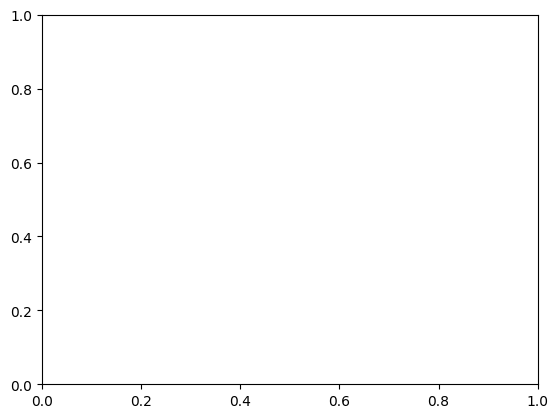

In [ ]:
import gymnasium as gym
import subprocess
import torch
import numpy as np
import random
from src.train import train_agent
from src.utils import SEMILLA
from src.policies.epsilon_greedy import EpsilonGreedyPolicy
from src.features_extractors.tile import TileCodingExtractor
from src.utils import extract_v_and_policy_continuous
from src.agents import AgentSarsaSemiGradient
from src.agents.deep_qlearning import AgentDeepQLearning
from src.rnn.qnetwork import QNetwork
from src.plots import (
    plot_steps_per_episode,
    plot_cost_to_go,
    plot_policy_comparison
)

try:
    # Intentar detectar si ipywidgets funciona correctamente
    import ipywidgets
    from src.evaluate_mountaincar_visual import evaluate_mountaincar_visual

    print("✓ Usando versión con widgets (VS Code)")
except:
    # Fallback para PyCharm
    from src.evaluate_mountaincar_visual_pycharm import evaluate_mountaincar_visual

    print("✓ Usando versión compatible con PyCharm")

In [ ]:
def setup_colab_reproducible_env():
    """
    Fuerza la instalación de versiones específicas en Google Colab
    para replicar el entorno local del usuario.
    """
    # Comprobar si estamos en Google Colab
    IN_COLAB = 'google.colab' in sys.modules
    
    if not IN_COLAB:
        print("Entorno local detectado. Saltando instalación forzada para evitar conflictos.")
        return

    print("--- Configurando entorno en Google Colab ---")
    print(f"Versión de Python actual: {sys.version}")

    # Lista de tus librerías con versión exacta (==)
    packages = [
        "numpy==2.4.2",
        "arms==2.1.0",
        "plotting==0.0.7",
        "seaborn==0.13.2",
        "matplotlib==3.10.8",
        "swig==4.4.1",
        "gymnasium[box2d]==1.2.3",
        "scikit-learn==1.8.0",
        "ipywidgets==8.1.8",
        "pandas==3.0.1",
        "pygame==2.6.1",
        "torch==2.10.0"
    ]

    for package in packages:
        try:
            # Instalamos usando el ejecutable actual de python para asegurar consistencia
            subprocess.check_call([sys.executable, "-m", "pip", "install", package, "--quiet"])
            print(f"Instalado con éxito: {package}")
        except Exception as e:
            print(f"Error al instalar {package}: {e}")

    print("\n--- ¡Entorno preparado! ---")
    print("RECOMENDACIÓN: Ve a 'Entorno de ejecución' > 'Reiniciar sesión' para aplicar cambios.")

# Ejecución de la función
setup_colab_reproducible_env()

In [ ]:
random.seed(SEMILLA)
np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)
torch.use_deterministic_algorithms(True, warn_only=True)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEMILLA)
    torch.cuda.manual_seed_all(SEMILLA)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
os.environ['PYTHONHASHSEED'] = str(SEMILLA)

# Creamos el entorno de Mountain Car
env = gym.make("MountainCar-v0", render_mode="rgb_array", goal_velocity=0.0)
env.action_space.seed(SEMILLA)
state, info = env.reset(seed=SEMILLA)

# Mountain Car con Agente SARSA Semi-Gradiente

Para este notebook, vamos a utilizar el entorno de mountain car, que es un entorno con un espacio de acciones continuo, que hace que no se pueda ejecutar con metodos tabulares. Vamos a empezar ejecutando el entorno con el agente SARSA semi-gradiente. Este algoritmo es On-Policy, por lo que la política de comportamiento y la objetivo serán la misma, y solo será necesario escoger una. La política elegida ha sido $\epsilon$-greedy con un $\epsilon$ de 0.01, ya que tiene la suficiente exploración para que el algoritmo converja, y podrá explotar de mejor manera las opciones con mejor recompensa. Para el extractor de características, vamos a utilizar *tile coding extractor*, ya que es lo suficiente potente y es más eficiente que otros extractores de características.

In [4]:
alpha = 0.05
gamma = 1
epsilon = 0.01

# Inicializar el feature extractor optimizado
feature_extractor = TileCodingExtractor(env)
# Calcular número de características usando el extractor
test_state, _ = env.reset()
test_features = feature_extractor(test_state, 0)
n_features = len(test_features)

# Inicializamos la política con la semilla
policy = EpsilonGreedyPolicy(epsilon=epsilon, n_actions=env.action_space.n, seed=SEMILLA)  # Política

# El agente usa las políticas
agent_tile = AgentSarsaSemiGradient(
    env=env,
    policy=policy,
    feature_extractor=feature_extractor,
    n_features=n_features,
    alpha=alpha,
    gamma=gamma
)

# Antes de iniciar el entrenamiento, lo reiniciamos pasándole la semilla
state, info = env.reset(seed=SEMILLA)

In [5]:
print(env.observation_space)
print(env.action_space)

Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Discrete(3)


## Visualización de juego pre-entrenamiento

In [ ]:
results_before = evaluate_mountaincar_visual(
    env, agent_tile,
    n_episodes=5,
    seed_base=SEMILLA,
    delay=0
)

print(results_before)

## Entrenamiento del Agente

In [ ]:
episode_returns_tile, episode_lengths_tile = train_agent(
    env,
    agent_tile,
    n_episodes=4000,
    max_steps=200,
    print_freq=500
)

## Visualización Gráfica del juego

In [ ]:
results_after_tile = evaluate_mountaincar_visual(
    env, agent_tile,
    n_episodes=5,
    seed_base=SEMILLA + 10000,
    delay=0
)
print(results_after_tile)

# Mountain Car con Agente Deep Q Learning

Ahora vamos a ejecutar el entorno con el agente Deep Q-Learning. En este caso, solo tenemos que elegir la política de comportamiento, ya que en vez de política objetivo se usará una red neuronal. Como política usaremos $\epsilon$-greedy con un $\epsilon$ de 0.01, ya que tiene la suficiente exploración para que el algoritmo converja, y podrá explotar de mejor manera las opciones con mejor recompensa. Para la red neuronal, vamos a utilizar un perceptrón multicapa con 2 capas ocultas de 128 neuronas, que es lo suficiente complejo para este entorno.

In [ ]:
# Creamos la red neuronal para Deep Q-Learning
q_network = QNetwork(state_dim=2, action_dim=3, hidden_dim=128)

# Inicializamos la política de comportamiento
policy_dql = EpsilonGreedyPolicy(epsilon=epsilon, n_actions=env.action_space.n, seed=SEMILLA)

# Creamos el agente Deep Q-Learning
agent_dql = AgentDeepQLearning(
    env=env,
    behavior_policy=policy_dql,
    q_network=q_network,
    lr=1e-4,
    buffer_size=20000,
    batch_size=64,
    update_frequency=1,
    gamma=0.99,
    seed=SEMILLA
)
print(f"Dispositivo donde ejecutar red neuronal de Deep Q-Learning: {agent_dql.device}")

# Reiniciamos el entorno con la semilla
state, info = env.reset(seed=SEMILLA)

In [ ]:
print(env.observation_space)
print(env.action_space)

## Visualización de juego pre-entrenamiento

In [ ]:
results_before_dql = evaluate_mountaincar_visual(
    env, agent_dql,
    n_episodes=5,
    seed_base=SEMILLA,
    delay=0
)
print(results_before_dql)

## Entrenamiento del Agente

In [ ]:
episode_returns_dql, episode_lengths_dql = train_agent(
    env,
    agent_dql,
    n_episodes=4000,
    max_steps=200,
    print_freq=500
)

## Visualización Gráfica del juego

In [ ]:
results_after_dql = evaluate_mountaincar_visual(
    env, agent_dql,
    n_episodes=5,
    seed_base=SEMILLA + 10000,
    delay=0
)
print(results_after_dql)

# Análisis de resultados y comparativa

### Número de pasos por episodio

In [ ]:
plot_steps_per_episode(
    [episode_lengths_tile, episode_lengths_dql],
    ["SARSA Semi-Gradient", "Deep Q-Learning"],
    window=25
)

**Ejes de la gráfica**

- **Eje horizontal (Episodio)**: Representa el número del episodio, para ver la evolución a lo largo de todo el entrenamiento.
- **Eje vertical (Pasos por episodio)**: Representa el número de pasos que ha tardado el agente en terminar el episodio. Cuanto más bajo sea el valor, menos pasos habrá tardado el agente en terminar, por lo que habrá tardado menos tiempo.

Con esta gráfica, podremos ver que tan rápido han aprendido los agentes y como de eficientes son sus soluciones a lo largo del tiempo.

---

**SARSA semi-gradient**

- Presenta una caida drástica en el número de pasos casi de inmediato (primeros 500 pasos), por lo que el algoritmo ha conseguido encontrar rápidamente una estrategia balanceada que le consigue escalar la montaña. Esto puede deberse a la función lineal que utiliza SARSA, ya que con pocos datos es capaz de formar una buena estrategia como la que ha conseguido.
- El agente se estabiliza en un rango entre 110 y 130 pasos por episodio, siendo bastante eficiente. Aunque podemos ver oscilaciones, en general la tendencia es consistente, sobre todo a partir del episodio 4000.

---

**Deep Q-Learning**

- Podemos ver que durante los primeros ~600 episodios el algoritmo no consigue reducir el número de pasos. Esto es normal, ya que las redes neuronales necesitan tiempo para ser entrenadas, y el Replay Buffer necesita tiempo para poder llenarse con experiencias antes de poder mejorar su política.
- A partir del episodio 600, podemos ver una caida muy drástica del número de episodios hasta el episodio ~750, llegando hasta los 125 pasos aproximadamente. A partir de aquí, el algoritmo se mantiene entre 125 y 150 pasos por episodio hasta llegar al episodio 3000.
- En el episodio 3000, podemos ver una subida momentanea que lleva al algoritmo de nuevo hasta los 200 pasos por episodio, aunque rápidamente vuelve a bajar. Esta subida espontanea puede deberse a dos factores: por un lado, las redes neuronales pueden a llegar a ser inestables, y una serie de malas actualizaciones puede hacer que la red olvide como llegar a la meta. Por otro lado, Deep Q-Learning es un algoritmo demasiado optimista, que durante esos episodios ha podido pensar que ciertas acciones generaban buenas recompensas, cuando en realidad eran malas decisiones. Después de la bajada, el algoritmo se ha mantenido entre los 100 y 140 pasos por episodio aproximadamente.

---

**Conclusiones**

- Consideramos que SARSA semi-gradiente es superior a Deep Q-Learning en este caso, ya que consigue una convergencia más rápida y resultados más consistentes y mejores a lo largo de prácticamente todos los episodios. Esto puede deberse a que SARSA es On-Policy, y además usa aproximadores lineales, por lo que puede generalizar de forma muy suave en espacios de estados continuos. DQL, al ser Off-Policy y usar redes neuronales, es un algoritmo más complejo que en problemas tan sencillos como este puede no generalizar tan bien como lo ha conseguido SARSA.

### Superficie de Valores de Estado

In [ ]:
pos_ssg, vel_ssg, v_grid_ssg, policy_grid_ssg = extract_v_and_policy_continuous(env, agent_tile)
pos_dql, vel_dql, v_grid_dql, policy_grid_dql = extract_v_and_policy_continuous(env, agent_dql)

plot_cost_to_go(pos_ssg, vel_ssg, v_grid_ssg, agent_name="SARSA Semi-Gradient")
plot_cost_to_go(pos_dql, vel_dql, v_grid_dql, agent_name="Deep Q-Learning")

**Ejes de la gráfica**

- **Eje X (Posición)**: Representa la posición del agente.
- **Eje Y (Velocidad)**: Representa la velocidad del agente.
- **Eje Z (Superficie de valores)**: Representa los pasos estimados que tomará el agente hasta llegar al objetivo.

Con esta gráfica, podremos ver la estimación que toma el agente en cuanto a los pasos que necesitará para terminar el episodio según la posición y velocidad actuales. Los puntos más altos muestran estados donde el agente piensa que tardará mucho en alcanzar su objetivo.

---

**SARSA semi-gradient**

- El rango Z llega hasta los 120 pasos. Esto es coherente viendo los resultados de la gráfica anterior, ya que el agente terminaba los episodios con esa cantidad de pasos aproximadamente. Esto nos indica que la estimación del agente es muy realista.
- Las arrugas de la superficia indican que el algoritmo ha podido identificar con bastante precisión los puntos donde gana o pierde la inercia necesaria para poder subir la montaña. Esto puede deberse gracias a que el algoritmo es On-Policy y sus aproximadores lineales consiguen una estimación bastante precisa de cada estado.

---

**Deep Q-Learning**

- El rango Z llega solo hasta los 70 pasos, y en la base de la gráfica podemos ver incluso valores negativos. Esto se debe a que el agente tiene un comportamiento demasiado optimista, y cree que puede terminar el episodio más rápido de lo que en realidad puede. Este caracter optimista es muy típico del algoritmo Q-Learning.
- La gráfica en general es muy suave, por lo que parece que la red neuronal no está consiguiendo distinguir entre estados similares pero con consecuencias distintas, eliminando detalles importantes de la gráfica.

---

**Conclusiones**

- SARSA, al ser On-Policy y más simple, está siendo un algoritmo más realista, que aprende basándose en lo que está haciendo cada paso y consigue crear un mapa de la montaña muy preciso. Mientras tanto, DQN se queda atrás por ser demasiado optimista y además, al usar una red neuronal en un problema tan sencillo, está simplificando demasiado el terreno, haciendo que las decisiones tomadas no sean del todo correctas y pueda llegar a tomar más tiempo del necesario en llegar al objetivo.

### Mapa de elecciones del agente

In [ ]:
plot_policy_comparison(
    agents=[agent_tile, agent_dql],
    labels=["SARSA Semi-Gradient", "Deep Q-Learning"],
    env=env,
    resolution=100
)

**Explicación de la gráfica**

- **Eje horizontal (Posición)**: Representa la posición del agente.
- **Eje vertical (Velocidad)**: Representa la velocidad del agente.
- **Linea negra (Camino agente)**: Representa el camino tomado por el agente hasta llegar al objetivo.
- **Región roja, gris y verde (Decisión del agente)**: Representa la decisión que tomaria el agente según su posición y velocidad actuales.

Con esta gráfica, podemos ver las decisiones que tomaría el agente según la posición y velocidad actuales, y un ejemplo de camino que tomaría para llegar a la meta. Hay que tener en cuenta que el punto de inicio del coche en el entorno es aleatorio, por lo que más que analizar cuanto tiempo toma el agente en llegar a la meta en la gráfica, debemos de analizar las areas de decisión.

---

**SARSA semi-gradient**

- Las areas de decisión del agente, aunque tienen un poco de ruido, en general son bastante suaves y están bien delimitadas, por lo que el agente ha conseguido generalizar bien las regiones de éxito.
- El camino del agente es una espiral limpia, que nos muestra que el algoritmo tiende a ser más conservador y estable, debido a que actualiza su conocimiento basándose en la acción que realmente va a tomar.

---

**Deep Q-Learning**

- Las areas de decisión son bastante similares a las de SARSA: podemos ver algo de ruido en general, pero las regiones principales son suaves y están bien delimitadas, por lo que el agente ha conseguido generalizar también las regiones de éxito. El camino del agente también podemos comprobar que es una espiral bastante limpia.

---

**Conclusiones**

- Ambas gráficas muestran como el agente debe "balancearse" para llegar al objetivo, tomando la decisión de ir hacia la derecha con velocidad positiva para seguir subiendo la colina, y yendo hacia la izquierda con velocidad negativa para coger inercia.
- En SARSA semi-gradiente podemos ver areas de decisión con forma más cuadrada, mientras que en Deep Q-Learning podemos ver formas más irregulares. SARSA genera la gráfica de esta manera debido al uso de *tile coding*, ya que divide el espacio de estados en una cuadricula. En el caso de DQL, al usar redes neuronales con funciones matemáticas continuas, no dividen el espacio de estados en bloques tan diferenciados.
- Ambas gráficas se ven muy suaves y bien delimitadas, pero viendo los resultados de la gráfica de número de pasos por episodio, podemos ver que SARSA ha funcionado un poco mejor. Esto puede significar que, aunque ambos agentes han conseguido converger a una buena política, SARSA ha conseguido detectar de mejor manera las acciones a tomar en cada estado, y DQL al usar redes neuronales, no ha conseguido adaptarse de forma tan buena al problema.